1. Look at the dataset
    - Different sizes of images
    - Samples with wrong labels
    - Different backgrounds
    - File formats
    - Intensity range
    - Class distribution
2. Pre-process the data
    - Padded the images so they are square
    - Resized the images to a managable size
3. Experimental setup
    -   Single train/val/test split: 70%/ 15%/ 15%
    -   Set data augmentation
    -   Create data loaders
4. Transfer learning
    - SOTA models on imagenet
    - Add and train new top/predictor
    - Fine-tune all or some feature learning layers 
5. Loss and metrics
    -   Loss: categorical cross-entropy
    -   Metrics: Accuracy, sensitivity, specificity, confusion matrix, training and inference time?
6. Set your callbacks and track your experiments
    - Early stopping - patience
    - Model check point
    - Learning rate scheduler
    - Weights and biases (train/val loss)
7. Set your main hyperparameters
    - batch size
    - learning rate
    - number of epochs
8. Train 
    - Train your model
    - Need to write your training code in pure Python and PyTorch or use another library like lightning or ignite
9. Test 
    - Run prediction on your test set
    - Extract relevant metrics
    - Measure inference time

- Other suggestions:
    - Use config files to make experimenting different configs easily
    - Design locally, but run experiments in the cluster



In [112]:
import os
import torch
import glob
import time
import matplotlib.pylab as plt
from torch.utils.data import Dataset
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from torchvision.models import ResNet18_Weights, ResNet50_Weights
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import wandb

# Use MPS on Apple Silicon when available, otherwise fall back to CPU.
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)



mps


In [113]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_ROOT = PROJECT_ROOT / "output"
TRAIN_PATH = str(OUTPUT_ROOT / "train_balanced")
VAL_PATH = str(OUTPUT_ROOT / "validation_balanced")
TEST_PATH = str(OUTPUT_ROOT / "test_balanced")

WANDB_ENTITY = "william-em-watson-university-of-calgary-in-alberta"
WANDB_PROJECT = "ai-gen-image-detection"
WANDB_API_KEY = os.getenv("WANDB_API_KEY", "")


In [114]:
# Transforms
# Tune image_size if you want to trade off speed vs. detail preservation.
image_size = 224

# ImageNet normalization is required when using pretrained ResNet weights.
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    # Tune augmentation here if the model starts overfitting.
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load datasets
train_dataset = ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_dataset = ImageFolder(root=VAL_PATH, transform=val_test_transform)
test_dataset = ImageFolder(root=TEST_PATH, transform=val_test_transform)

# Tune batch_size depending on available memory.
batch_size = 16
# On local notebooks, num_workers=0 is often the safest starting point.
num_workers = 0

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)



In [115]:
class_names = train_dataset.classes
print(class_names)
print('Train set:', len(train_dataset))
print('Val set:', len(val_dataset))
print('Test set:', len(test_dataset))



['ai_generated', 'real']
Train set: 3800
Val set: 608
Test set: 856


In [116]:
train_iterator = iter(trainloader)
train_batch = next(train_iterator)

In [117]:
print(train_batch[0].size())
print(train_batch[1].size())

torch.Size([16, 3, 224, 224])
torch.Size([16])


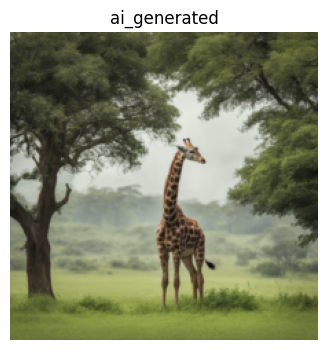

In [118]:
# Visualize one normalized training image.
# We undo normalization here so the image displays correctly.
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

sample_image = train_batch[0][2].cpu() * std + mean
sample_image = sample_image.clamp(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(sample_image.permute(1, 2, 0).numpy())
plt.title(class_names[train_batch[1][2].item()])
plt.axis('off')
plt.show()



In [119]:
class AiGenModel(nn.Module):
    def __init__(self, num_classes=2, transfer=True, freeze_backbone=True):
        super().__init__()

        self.transfer = transfer
        self.freeze_backbone = freeze_backbone

        weights = ResNet50_Weights.DEFAULT if transfer else None
        self.feature_extractor = models.resnet50(weights=weights)

        if self.transfer and self.freeze_backbone:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        in_features = self.feature_extractor.fc.in_features
        # Tune this head if you want something deeper than a single linear layer.
        self.feature_extractor.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.feature_extractor(x)



In [120]:
num_classes = len(class_names)
# Start frozen for stability. Later, we can unfreeze some backbone layers if needed.
net = AiGenModel(num_classes=num_classes, transfer=True, freeze_backbone=True).to(device)
print(net)



AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [121]:
criterion = nn.CrossEntropyLoss()
# Tune learning_rate and weight_decay here.
learning_rate = 1e-3
weight_decay = 1e-4

trainable_params = [param for param in net.parameters() if param.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)
# This scheduler is a good default for transfer learning.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
else:
    print('WANDB_API_KEY is not set. Export it in your environment before training if you want W&B logging.')

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    config={
        'train_path': TRAIN_PATH,
        'val_path': VAL_PATH,
        'test_path': TEST_PATH,
        'model_name': 'resnet50',
        'transfer_learning': True,
        'freeze_backbone': True,
        'image_size': image_size,
        'batch_size': batch_size,
        'num_workers': num_workers,
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'num_classes': num_classes,
        'device': str(device),
    },
)

# W&B automatically captures available system metrics (CPU, memory, disk, GPU when supported).
wandb.define_metric('epoch')
wandb.define_metric('train_loss', step_metric='epoch')
wandb.define_metric('train_acc', step_metric='epoch')
wandb.define_metric('val_loss', step_metric='epoch')
wandb.define_metric('val_acc', step_metric='epoch')
wandb.define_metric('learning_rate', step_metric='epoch')
wandb.define_metric('epoch_time_sec', step_metric='epoch')
wandb.watch(net, criterion, log='all', log_freq=50)



wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/williamwatson/.netrc


In [122]:
# Tune nepochs and patience depending on how quickly validation loss plateaus.
nepochs = 1
PATH = './genai_resnet50_best.pth'

wandb.config.update({'nepochs': nepochs}, allow_val_change=True)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(nepochs):
    epoch_start_time = time.perf_counter()
    net.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_dataset)
    train_acc = train_correct / train_total

    net.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_dataset)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time_sec = time.perf_counter() - epoch_start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'learning_rate': current_lr,
        'epoch_time_sec': epoch_time_sec,
    })

    print(
        f'Epoch {epoch + 1}/{nepochs} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
    )

    if val_loss < best_val_loss:
        print('Saving best model')
        torch.save(net.state_dict(), PATH)
        best_val_loss = val_loss
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_epoch'] = epoch + 1

print('Finished training')



Epoch 1/1 | train_loss=0.5275 train_acc=0.7505 | val_loss=0.4277 val_acc=0.8322
Saving best model
Finished training


In [123]:
# Load the best model before evaluating on the test set.
net = AiGenModel(num_classes=len(class_names), transfer=True, freeze_backbone=True).to(device)
net.load_state_dict(torch.load(PATH, map_location=device))
net.eval()



AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequentia

In [124]:
correct = 0
total = 0
test_loss = 0.0

test_start_time = time.perf_counter()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_inference_time_sec = time.perf_counter() - test_start_time
test_loss = test_loss / len(test_dataset)
test_accuracy = correct / total

test_metrics = {
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'test_accuracy_percent': 100 * test_accuracy,
    'test_inference_time_sec': test_inference_time_sec,
}
wandb.log(test_metrics)
for key, value in test_metrics.items():
    wandb.run.summary[key] = value

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {100 * test_accuracy:.2f}%')
print(f'Test inference time: {test_inference_time_sec:.2f}s')



Test loss: 0.7885
Test accuracy: 57.01%
Test inference time: 15.19s


In [125]:
# Optional: per-class accuracy helps us see whether one class is being ignored.
class_correct = {name: 0 for name in class_names}
class_total = {name: 0 for name in class_names}

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            class_name = class_names[label.item()]
            class_total[class_name] += 1
            if label.item() == pred.item():
                class_correct[class_name] += 1

for class_name in class_names:
    accuracy = class_correct[class_name] / max(class_total[class_name], 1)
    print(f'{class_name}: {100 * accuracy:.2f}% ({class_correct[class_name]}/{class_total[class_name]})')
    wandb.log({f'test_accuracy_{class_name}': accuracy})
    wandb.run.summary[f'test_accuracy_{class_name}'] = accuracy



ai_generated: 74.53% (319/428)
real: 39.49% (169/428)


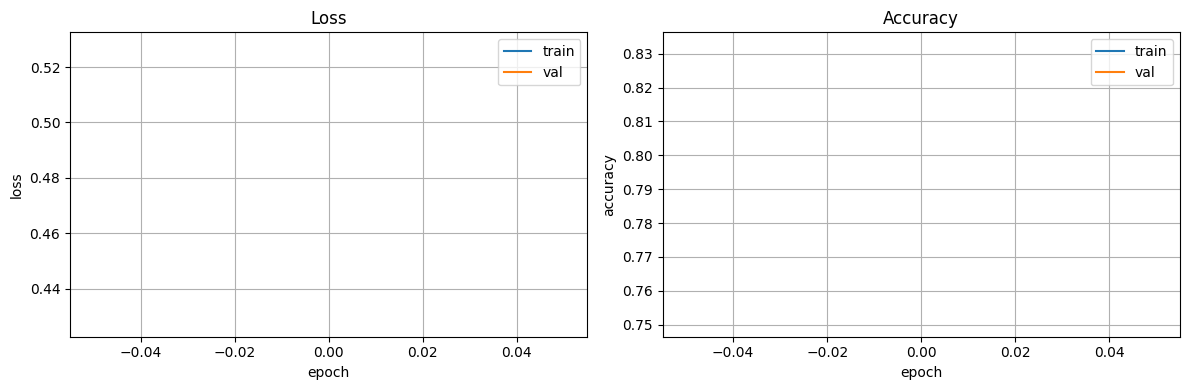

In [126]:
# Optional: visualize training curves.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# W&B already turns the logged epoch metrics into charts automatically.



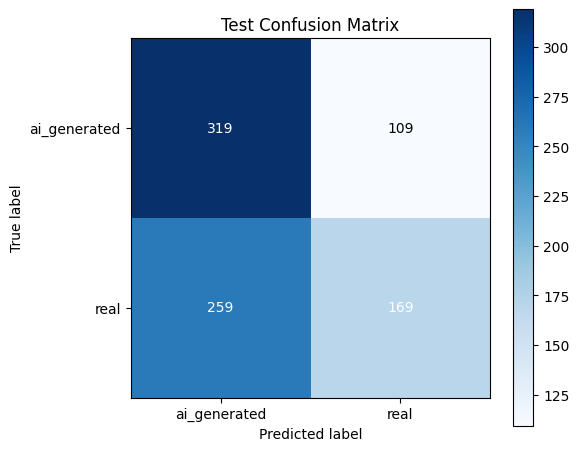

epoch,▁
epoch_time_sec,▁
learning_rate,▁
test_accuracy,▁
test_accuracy_ai_generated,▁
test_accuracy_percent,▁
test_accuracy_real,▁
test_inference_time_sec,▁
test_loss,▁
train_acc,▁
+3,...


In [127]:
# Optional: plot the test-set confusion matrix.
confusion_matrix = torch.zeros((len(class_names), len(class_names)), dtype=torch.int64)

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[label.item(), pred.item()] += 1

cm = confusion_matrix.cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Test Confusion Matrix')

threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()

wandb.finish()
